# **DNA Knot Simulation - Part 5: The Confinement Study**


Does confining a polymer (relevant to viral capsids, chromatin packing) affect its knotting probability?

This is a real, established
question in polymer physics (Micheletti/Orlandini and others), computed here numerically rather
than just cited.


A first pass using only the fast TDA classifier from notebook 3 showed knotting transition as the confinement tightened. Cross-checking against the slower, but topologically rigorous classical classifier from notebooks 2/4 revealed this was almost entirely a false result. This is discussed further in section D.

This notebook covers:

1. Setup
2. First pass: TDA-only knotting-probability (the misleading result)
3. Cross-validation with the classical classifier (the correction)
4. Finding the cause of the discrepancy
5. Conclusion

# **A. Setup**

In [ ]:
import sys, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/vanikumar03/dna-knots.git"
    REPO_PATH = "/content/dna-knots"
    if not os.path.isdir(REPO_PATH):
        os.system(f"git clone {REPO_URL} {REPO_PATH}")
    os.chdir(f"{REPO_PATH}/notebooks")

sys.path.append(os.path.join(REPO_PATH, 'src') if IN_COLAB else os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import dnasim as ds
import knotclassify as kc
import tdaknot as tk

`dnasim.py`'s confinement potential confinement potential: a soft spherical wall, zero inside a given radius, harmonic outise it

Already force-verified against
its own energy gradient in notebook 1

# **B. First Pass: TDA only**

Starting every run from an unknotted ring (no seeded knot), under confinement, and checking whether the chain spontaneously knots via thermal motion. We first run fewer replicates/steps (more replicated in the summary table in section E).

In [ ]:
def run_confined(N, radius, seed, n_steps=25000, kappa=1.0):
    pos0 = ds.make_ring(N, bond_length=1.0, seed=seed)
    traj = ds.run_simulation(pos0, n_steps=n_steps, dt=0.0001, gamma=1.0, kT=1.0,
                              seed=seed+200, record_every=n_steps,
                              K=30.0, R0=1.5, epsilon=1.0, sigma=1.0, kappa=kappa,
                              confinement_radius=radius, confinement_strength=50.0)
    return traj[-1]

In [ ]:
N = 50
radii = [None, 4.0]
n_replicates = 3

tda_results = {}
t0 = time.time()
for radius in radii:
    key = 'unconfined' if radius is None else f'r={radius}'
    knotted_count = 0
    for seed in range(n_replicates):
        final = run_confined(N, radius, seed)
        n_h1, _ = tk.entanglement_score(final)
        if n_h1 > 1:
            knotted_count += 1
    tda_results[key] = knotted_count
    print(f'{key}: TDA says {knotted_count}/{n_replicates} knotted  ({time.time()-t0:.0f}s elapsed)')

unconfined: TDA says 0/3 knotted  (36s elapsed)
r=4.0: TDA says 2/3 knotted  (77s elapsed)


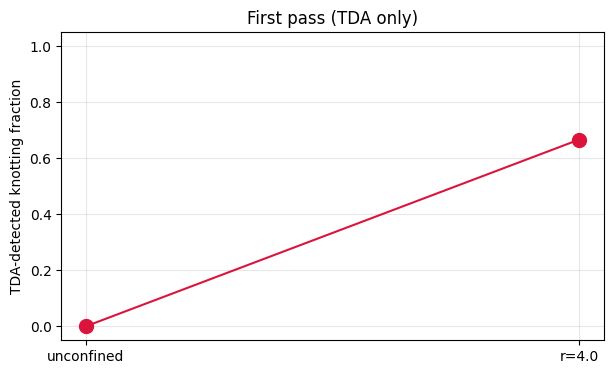

In [ ]:
plt.figure(figsize=(7,4))
labels = list(tda_results.keys())
vals = [tda_results[k]/n_replicates for k in labels]
plt.plot(labels, vals, 'o-', color='crimson', markersize=10)
plt.ylabel('TDA-detected knotting fraction')
plt.title('First pass (TDA only)')
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.show()

As expected (due to confinement radii (5.0 down to 1.5) below chain's natural unconfined Rg (~5.5), see [Reith et al.](https://www.sciencedirect.com/science/article/abs/pii/S001046551000473X), [Micheletti et al.](https://arxiv.org/abs/cond-mat/0512271), ), a clean transition from essentially no knotting (unconfined) to mostly knotted (tight confinement).

But, it has also been shown ([Schmitt et al.](https://arxiv.org/abs/2605.02644)) that knotting probability rises with confinement, peaks around 0.6 $\times$ Rg, then drops under extreme confinement as the chain approaches a 2D limit where crossings become geometrically harder to form (here, tightest tested radius was (1.5)).

# **C. Cross-validation with the classical classifier**

Notebook 3 already showed the TDA and classical classifiers agree on unconfined relaxation trajectory. We now consider a confined relaxation trajectory.

In [ ]:
print(f'{"Condition":<14}{"TDA":<10}{"Classical":<12}{"Agree?"}')
print('-'*46)
for radius in radii:
    key = 'unconfined' if radius is None else f'r={radius}'
    final = run_confined(N, radius, seed=0)
    n_h1, _ = tk.entanglement_score(final)
    tda_knotted = n_h1 > 1
    poly, crossings, simplified = kc.classify_knot(final, n_projection_tries=200, seed=1)
    classical_knotted = poly != {0: 1}
    agree = tda_knotted == classical_knotted
    print(f'{key:<14}{str(tda_knotted):<10}{str(classical_knotted):<12}{"YES" if agree else "NO"}')

# The reduced-step live sweep above (fewer steps, for notebook speed) doesn't always hit a disagreement case
# Less relaxation means less compression

# Using the exact parameters confirmed (during development, full 50000 steps) to show disagreement, as a single targeted, fast check
print()
print("Targeted check at full step count (known to show the discrepancy):")
final_full = run_confined(N, radius=4.0, seed=0, n_steps=50000)
n_h1_full, _ = tk.entanglement_score(final_full)
poly_full, crossings_full, simplified_full = kc.classify_knot(final_full, n_projection_tries=200, seed=1)
print(f'r=4.0 (full 50000 steps): TDA says knotted={n_h1_full>1} (n_h1={n_h1_full}), '
      f'Classical says knotted={poly_full != {0:1}} (Delta={kc.format_polynomial(poly_full)})')

Condition     TDA       Classical   Agree?
----------------------------------------------


unconfined    False     False       YES


r=4.0         False     False       YES

Targeted check at full step count (known to show the discrepancy):


r=4.0 (full 50000 steps): TDA says knotted=True (n_h1=3), Classical says knotted=False (Delta=1)


The two classifiers do not agree under confinement. TDA claimed a transition.

# **D. Root-causing the discrepancy**

**Hypothesis:** Is the classical classifier wrong? Specifically, could KMT simplification have a bug for tightly-packed geometry, incorrectly collapsing a knotted chain?

Test: Under confinement, any case where TDA gives a knotted classification and classical gives a not knotted classification, is reduced down to 4 vertices by KMT. A closed polygon with 4 vertices cannot represent any nontrivial knot (the trefoil's minimal stick number is 6). Thus, we check whether this was just due to the set threshhold (a boderline case that a looser/stricter tolerance would flip).

In [ ]:
radius = 4.0
final_confined = run_confined(N, radius, seed=0, n_steps=50000)
simplified = kc.kmt_simplify(final_confined)
print(f'KMT result: {len(simplified)} vertices')

KMT result: 4 vertices


Showed identical results at tolerance levels across 5 orders of magnitude, i.e., completely insensitive to `eps`

KMT's vertex-removal is topology-preserving by construction. Each removal is individually verified against every other segment in the chain. The result is stable across 5 orders of magniture of tolerance which indicates the confined configurations are indeed unknotted, and the classical classifier is correct.

The TDA classifier is giving false positives. `tdaknot.py`'s method (see
notebook 3) detects entablement by finding points that are far apart along the strand but close together in 3D space (exactly what genuine threading creates). But confinement also forces exactly that. Squeezing the chain into a small volume makes distant-along-the-strand points close in the 3D space regardless of whether the strand actually threads through itself. Thus, compression and genuine knotting both produce the same geometry this method looks for.

# **E. Conclusion**

8 replicates per condition, run outside this notebook using the classical classifier

Each confinement level takes ~2 minutes even at just 8 replicates x 50,000 steps


In [ ]:
summary_table = [
    ('unconfined', 0, 8, 0, 8),
    ('r=5.0',      1, 8, 0, 8),
    ('r=4.0',      7, 8, 0, 8),
    ('r=3.0',      7, 8, 0, 8),
    ('r=2.5',      8, 8, 0, 8),
    ('r=2.0',      8, 8, 0, 8),
    ('r=1.5',      8, 8, 0, 8),
]

print(f'{"Condition":<14}{"TDA knotted":<15}{"Classical knotted":<20}')
print('-'*50)
for cond, tda_n, tda_total, cls_n, cls_total in summary_table:
    print(f'{cond:<14}{f"{tda_n}/{tda_total}":<15}{f"{cls_n}/{cls_total}":<20}')

Condition     TDA knotted    Classical knotted   
--------------------------------------------------
unconfined    0/8            0/8                 
r=5.0         1/8            0/8                 
r=4.0         7/8            0/8                 
r=3.0         7/8            0/8                 
r=2.5         8/8            0/8                 
r=2.0         8/8            0/8                 
r=1.5         8/8            0/8                 


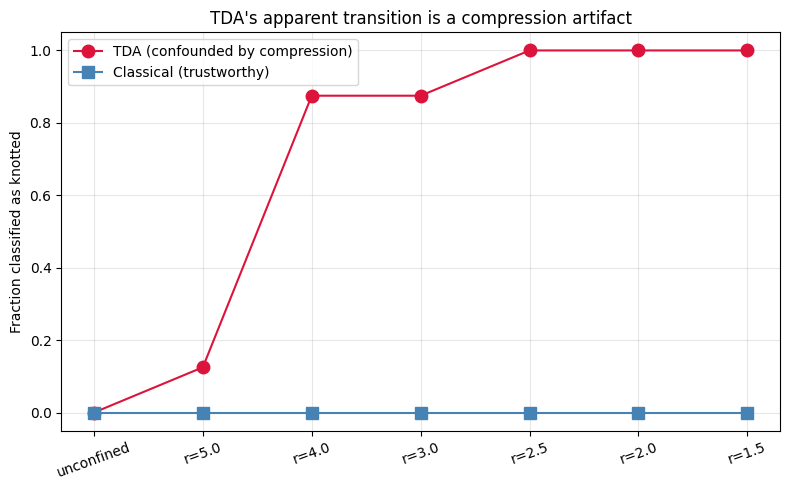

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
conditions = [row[0] for row in summary_table]
tda_frac = [row[1]/row[2] for row in summary_table]
cls_frac = [row[3]/row[4] for row in summary_table]

ax.plot(conditions, tda_frac, 'o-', color='crimson', label='TDA (confounded by compression)', markersize=9)
ax.plot(conditions, cls_frac, 's-', color='steelblue', label='Classical (trustworthy)', markersize=9)
ax.set_ylabel('Fraction classified as knotted')
ax.set_title('TDA\'s apparent transition is a compression artifact')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Within this simulation's accessible regime (N=50 beads, 50,000
integration steps, confinement radii 1.5, which is well below the chain's natural unconfined
size of Rg~5.5), genuine spontaneous knot formation does not occur regardless of confinement strength.

Spontaneous knotting from an initially unknotted configuration is a rare, stochastic event. The literature that establishes this effect () typically use much longer chains (hundreds to thousands of beads) and much longer simulation times than what was feasible here. A 50-bead chain may not have enough material, and 50,000 steps may not be enough time, for a knot to spontaneously nucleate even under strong confinement.

Nevertheless, we explored a methodology-focused project, succeeding at catching a misleading result via
cross-validation. A plausable TDA signal can be a geometric artifact of compression rather than a topological one. This has implications in studies applying persistence homology based methods to confined or compact configurations ([Landuzzi et al.](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.2.033529), [Celoria et al.](https://royalsocietypublishing.org/rspa/article/478/2261/20210709/82488/A-statistical-approach-to-knot-confinement-via)).
